# Gran Canaria Weekly Audit + EDA (GCAN)

**Project:** Climate–Mortality 

**Goal:** Produce a reproducible, weekly-level exploratory analysis for Gran Canaria, focusing on (1) data quality/coverage, (2) temperature (absolute vs anomaly), and (3) calima intensity signals, while being explicit about limitations.


## 0. Setup
Imports, path setup, and shared helper utilities.


In [30]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ISLAND_NAME = "gran_canaria"
ISLAND_CODE = "gcan"

CWD = Path.cwd().resolve()

# If running from islands/<island>, go up two levels to repo root
if CWD.name == ISLAND_NAME and CWD.parent.name == "islands":
    ROOT = CWD.parent.parent
else:
    ROOT = CWD

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("CWD :", CWD)
print("ROOT:", ROOT)
print("src exists?:", (ROOT / "src").exists())

# --- shared notebook helpers ---
from src.utils.d25_nb_utils import (
    section, glance, checks, missing_table, num_summary, set_island_paths,
    autosave_fig, save_table,
)

# --- reports output paths ---
REPORTS_DIR = ROOT / "reports" / "islands"
FIG_DIR = REPORTS_DIR / "figures" / ISLAND_NAME
TAB_DIR = REPORTS_DIR / "tables" / ISLAND_NAME

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

# --- data input ---
FP = ROOT / "data/processed" / ISLAND_NAME / "master" / f"master_{ISLAND_CODE}_2015_2024.parquet"
print("FP:", FP)

assert FP.exists(), f"Missing file: {FP}"


CWD : C:\dev\projects\climate_mortality\islands\gran_canaria
ROOT: C:\dev\projects\climate_mortality
src exists?: True
FIG_DIR: C:\dev\projects\climate_mortality\reports\islands\figures\gran_canaria
TAB_DIR: C:\dev\projects\climate_mortality\reports\islands\tables\gran_canaria
FP: C:\dev\projects\climate_mortality\data\processed\gran_canaria\master\master_gcan_2015_2024.parquet


## 1. Load data
Load the island master dataset and subset to Gran Canaria.


In [31]:
section("EDA core weekly Gran Canaria")

df = pd.read_parquet(FP)
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

if "island_code" in df.columns:
    df = df.loc[df["island_code"].eq("gcan")].copy()

glance(df, label="eda_core_weekly_gcan", n=5)
display(checks(df, required=["week_start", "deaths_week"], key=["week_start"], dt="week_start"))
display(num_summary(df))



EDA core weekly Gran Canaria

--- eda_core_weekly_gcan ---
shape: (471, 36)

dtypes:
 week_start                     datetime64[ns]
year                                    int32
island                                 object
island_code                            object
deaths_week                           float64
temp_c_mean                           float64
tmax_c_mean                           float64
tmin_c_mean                           float64
humidity_mean                         float64
pressure_hpa_mean                     float64
wind_ms_mean                          float64
low_vis_confirmed_days_week             int64
low_vis_confirmed_any_week              int64
low_vis_possible_days_week              int64
low_vis_possible_any_week               int64
low_vis_any_days_week                   int64
low_vis_any_week                        int64
confirmed_airports_max_week             int64
possible_airports_max_week              int64
airports_obs_max_week                  

,week_start,year,island,island_code,deaths_week,temp_c_mean,tmax_c_mean,tmin_c_mean,humidity_mean,pressure_hpa_mean,...,O3,days_with_pm10,days_missing_pm10,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag,calima_level_week
0,2015-12-28,2015,gran_canaria,gcan,133.0,19.500000,22.333333,16.666667,75.666667,1020.666667,...,69.333333,3,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,2016-01-04,2016,gran_canaria,gcan,126.0,19.400000,22.557143,16.242857,70.571429,1016.785714,...,64.142857,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,2016-01-11,2016,gran_canaria,gcan,127.0,20.528571,23.871429,17.214286,69.714286,1015.971429,...,54.857143,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,2016-01-18,2016,gran_canaria,gcan,135.0,20.071429,22.842857,17.285714,69.000000,1018.571429,...,65.000000,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,2016-01-25,2016,gran_canaria,gcan,136.0,20.100000,22.771429,17.400000,60.571429,1023.285714,...,74.857143,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0


,name,ok,detail
0,required_cols_present,True,ok
1,datetime_parse_week_start,True,bad=0
2,duplicates_on_key,True,dups=0
3,total_missing_cells,True,missing_cells=977
4,deaths_nonnegative,True,neg=0


,count,mean,std,min,25%,50%,75%,max
year,471.0,2019.993631,2.594996,2015.000000,2018.000000,2020.000000,2022.000000,2024.000000
deaths_week,471.0,134.309979,20.705675,89.000000,119.000000,133.000000,147.000000,209.000000
temp_c_mean,470.0,21.781848,2.643902,15.642857,19.503571,21.759524,24.064286,28.828571
tmax_c_mean,470.0,24.859832,2.754151,18.528571,22.575000,24.835714,26.967857,32.883333
tmin_c_mean,470.0,18.705002,2.601231,12.742857,16.407143,18.546429,21.100000,24.928571
humidity_mean,470.0,63.767837,5.728638,36.571429,60.857143,64.285714,67.142857,78.714286
pressure_hpa_mean,470.0,1013.232664,3.149706,1003.457143,1011.026786,1012.676190,1014.976786,1023.285714
wind_ms_mean,471.0,7.449376,2.616907,2.214286,5.321429,7.300000,9.235714,13.814286
low_vis_confirmed_days_week,471.0,2.067941,1.682087,0.000000,1.000000,2.000000,3.000000,7.000000
low_vis_confirmed_any_week,471.0,0.791932,0.406357,0.000000,1.000000,1.000000,1.000000,1.000000


In [32]:
# Minimal preparation used across later sections
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df["month"] = df["week_start"].dt.month
df = df.sort_values("week_start").reset_index(drop=True)

# Derive only the anomaly columns actually needed if missing
if "tmax_anom_mean" not in df.columns and "tmax_c_mean" in df.columns:
    monthly_ref = df.groupby("month")["tmax_c_mean"].transform("mean")
    df["tmax_anom_mean"] = df["tmax_c_mean"] - monthly_ref
    print("Created tmax_anom_mean from tmax_c_mean using month-of-year mean.")
else:
    print("tmax_anom_mean already present.")

if "excess_deaths" not in df.columns and "deaths_week" in df.columns:
    deaths_ref = df.groupby("month")["deaths_week"].transform("mean")
    df["excess_deaths"] = df["deaths_week"] - deaths_ref
    print("Created excess_deaths from deaths_week using month-of-year mean.")
else:
    print("excess_deaths already present or deaths_week missing.")


Created tmax_anom_mean from tmax_c_mean using month-of-year mean.
Created excess_deaths from deaths_week using month-of-year mean.


In [33]:
# Merge weekly calima proxy (kept external to the base master)
calima_fp = ROOT / "data" / "processed" / "gran_canaria" / "calima" / "calima_proxy_weekly_gcan_2015_2024_v2.parquet"
print("Calima proxy FP:", calima_fp)

if calima_fp.exists():
    calima = pd.read_parquet(calima_fp).copy()
    calima["week_start"] = pd.to_datetime(calima["week_start"], errors="coerce")

    keep = ["week_start", "calima_proxy_score_v2", "calima_proxy_level_v2"]
    extra_keep = [c for c in [
        "cap_dust_yellow_plus_week",
        "cap_dust_level_max_week",
        "calima_dai_flag",
    ] if c in calima.columns]

    calima_keep = [c for c in keep + extra_keep if c in calima.columns]

    overlap = [c for c in calima_keep if c != "week_start" and c in df.columns]
    if overlap:
        print("Dropping overlapping columns before merge:", overlap)
        df = df.drop(columns=overlap)

    df = df.merge(calima[calima_keep], on="week_start", how="left")
    print("Merged calima proxy columns:", [c for c in calima_keep if c != "week_start"])
else:
    print("Calima proxy weekly dataset not found. Section 6.1 will be skipped.")

print(df.shape)


Calima proxy FP: C:\dev\projects\climate_mortality\data\processed\gran_canaria\calima\calima_proxy_weekly_gcan_2015_2024_v2.parquet
Dropping overlapping columns before merge: ['cap_dust_yellow_plus_week', 'cap_dust_level_max_week', 'calima_dai_flag']
Merged calima proxy columns: ['calima_proxy_score_v2', 'calima_proxy_level_v2', 'cap_dust_yellow_plus_week', 'cap_dust_level_max_week', 'calima_dai_flag']
(471, 41)


## 2. QA / Audit
Minimal checks to confirm weekly uniqueness, required columns, and coverage.


In [34]:
qa = checks(df, required=["week_start", "deaths_week"], key=["week_start"], dt="week_start")
display(qa)

miss = missing_table(df)
display(miss.head(25))


,name,ok,detail
0,required_cols_present,True,ok
1,datetime_parse_week_start,True,bad=0
2,duplicates_on_key,True,dups=0
3,total_missing_cells,True,missing_cells=978
4,deaths_nonnegative,True,neg=0


,missing,missing_pct
calima_dai_flag,146,0.3100
calima_level_week,146,0.3100
cap_dust_yellow_plus_week,129,0.2739
cap_heat_yellow_plus_week,129,0.2739
cap_dust_level_max_week,129,0.2739
cap_heat_level_max_week,129,0.2739
cap_coverage_week,129,0.2739
SO2,17,0.0361
PM2.5,11,0.0234
O3,6,0.0127


In [35]:
save_table(qa, TAB_DIR, "qa_checks_gcan.csv", index=False)
save_table(miss.head(50), TAB_DIR, "missing_top50_gcan.csv")


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gran_canaria\qa_checks_gcan.csv
Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gran_canaria\missing_top50_gcan.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/gran_canaria/missing_top50_gcan.csv')

### Data coverage notes
- **CAP alerts are only usable from 2018 onwards** (pre-2018 coverage is not consistently available).
- **DAI flag data are not available after March 2022** (post-Mar-2022 coverage is missing).


## 3. Core descriptive statistics
Quick descriptive tables for the key variables used in the analysis.


In [36]:
core_cols = [
    "deaths_week",
    "temp_c_mean", "tmax_c_mean", "tmin_c_mean",
    "humidity_mean", "pressure_hpa_mean", "wind_ms_mean",
    "PM10", "PM2.5", "SO2", "NO2", "O3",
    "cap_heat_level_max_week", "cap_dust_level_max_week",
    "cap_heat_yellow_plus_week", "cap_dust_yellow_plus_week",
    "cap_coverage_week", "calima_dai_flag",
    "low_vis_any_week", "vis_min_m_week", "rh_min_pct_week"
]
desc = num_summary(df, cols=core_cols)
display(desc)
save_table(desc.reset_index().rename(columns={"index": "variable"}), TAB_DIR, "desc_core_gcan.csv", index=False)


,count,mean,std,min,25%,50%,75%,max
deaths_week,471.0,134.309979,20.705675,89.000000,119.000000,133.000000,147.000000,209.000000
temp_c_mean,470.0,21.781848,2.643902,15.642857,19.503571,21.759524,24.064286,28.828571
tmax_c_mean,470.0,24.859832,2.754151,18.528571,22.575000,24.835714,26.967857,32.883333
tmin_c_mean,470.0,18.705002,2.601231,12.742857,16.407143,18.546429,21.100000,24.928571
humidity_mean,470.0,63.767837,5.728638,36.571429,60.857143,64.285714,67.142857,78.714286
pressure_hpa_mean,470.0,1013.232664,3.149706,1003.457143,1011.026786,1012.676190,1014.976786,1023.285714
wind_ms_mean,471.0,7.449376,2.616907,2.214286,5.321429,7.300000,9.235714,13.814286
PM10,471.0,55.545395,62.507676,15.714286,33.142857,41.142857,54.357143,934.428571
PM2.5,460.0,19.424591,16.232243,3.500000,12.421429,16.000000,20.714286,217.857143
SO2,454.0,6.840319,4.008764,0.285714,3.857143,6.142857,9.000000,29.571429


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gran_canaria\desc_core_gcan.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/gran_canaria/desc_core_gcan.csv')

## 4. Time series overview
Weekly deaths and temperature series (context + seasonality).


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\gran_canaria\gcan_eda01_weekly_deaths_timeseries.png


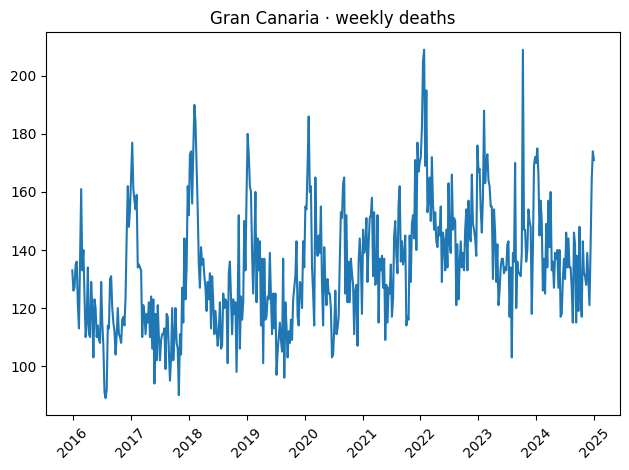

Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\gran_canaria\gcan_eda01_weekly_tmax_timeseries.png


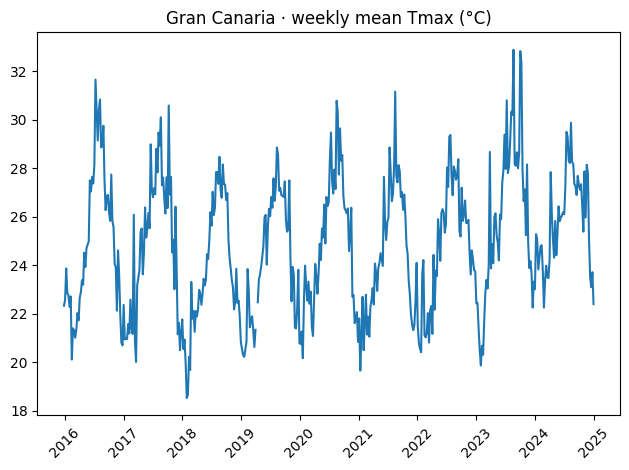

In [37]:
plt.figure()
plt.plot(df["week_start"], df["deaths_week"])
plt.title("Gran Canaria · weekly deaths")
plt.xticks(rotation=45)
plt.tight_layout()
autosave_fig(plt.gcf(), FIG_DIR, "gcan_eda01_weekly_deaths_timeseries.png")
plt.show()

plt.figure()
plt.plot(df["week_start"], df["tmax_c_mean"])
plt.title("Gran Canaria · weekly mean Tmax (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
autosave_fig(plt.gcf(), FIG_DIR, "gcan_eda01_weekly_tmax_timeseries.png")
plt.show()


## 5. Temperature and mortality
### 5.1 Absolute temperature vs deaths
Absolute temperature can be heavily confounded by seasonality.


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\gran_canaria\gcan_eda01_deaths_vs_absolute_tmax_scatter.png


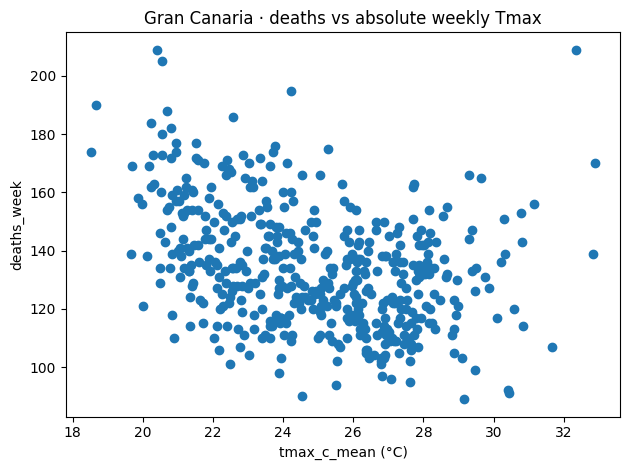

corr(deaths, tmax_c_mean): -0.365


In [38]:
plt.figure()
plt.scatter(df["tmax_c_mean"], df["deaths_week"])
plt.xlabel("tmax_c_mean (°C)")
plt.ylabel("deaths_week")
plt.title("Gran Canaria · deaths vs absolute weekly Tmax")
plt.tight_layout()
autosave_fig(plt.gcf(), FIG_DIR, "gcan_eda01_deaths_vs_absolute_tmax_scatter.png")
plt.show()

corr_abs = df[["deaths_week", "tmax_c_mean"]].corr().iloc[0, 1]
print("corr(deaths, tmax_c_mean):", round(float(corr_abs), 4))


##### 5.2 Temperature anomaly vs deaths
Use anomalies (relative temperature) to reduce seasonal confounding.


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\gran_canaria\gcan_eda01_deaths_vs_temperature_anomaly_scatter.png


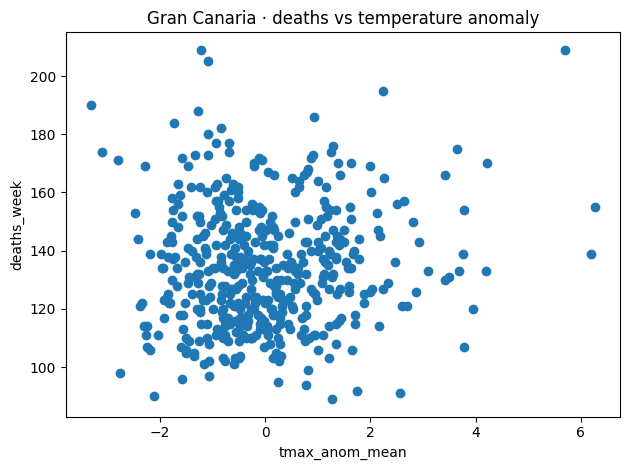

corr(deaths, tmax_anom_mean): 0.0822


In [39]:
anom_col = None
for c in ["tmax_anom_mean_week", "tmax_anom_mean", "tmax_anom_c_mean", "tmax_anom"]:
    if c in df.columns:
        anom_col = c
        break

if anom_col is None:
    print("No anomaly column found in this master. (Skip or create anomalies upstream.)")
else:
    plt.figure()
    plt.scatter(df[anom_col], df["deaths_week"])
    plt.xlabel(anom_col)
    plt.ylabel("deaths_week")
    plt.title("Gran Canaria · deaths vs temperature anomaly")
    plt.tight_layout()
    autosave_fig(plt.gcf(), FIG_DIR, "gcan_eda01_deaths_vs_temperature_anomaly_scatter.png")
    plt.show()
    corr_anom = df[["deaths_week", anom_col]].corr().iloc[0, 1]
    print(f"corr(deaths, {anom_col}):", round(float(corr_anom), 4))


### 5.3 Extreme heat (p90 / p95)
Compare weeks above an extreme threshold vs the rest.


In [40]:
# Official heat flags for this notebook
q90_tmax = df["tmax_c_mean"].quantile(0.90)
q95_tmax = df["tmax_c_mean"].quantile(0.95)

df["heat_p90"] = (df["tmax_c_mean"] >= q90_tmax).astype(int)
df["heat_p95"] = (df["tmax_c_mean"] >= q95_tmax).astype(int)

print(f"Official heat thresholds from tmax_c_mean -> p90={q90_tmax:.2f}, p95={q95_tmax:.2f}")
print(df["heat_p95"].value_counts(dropna=False))

tab_p95 = df.groupby("heat_p95")["deaths_week"].agg(["count", "mean", "median"])
display(tab_p95)

if 0 in tab_p95.index and 1 in tab_p95.index:
    delta_p95 = float(tab_p95.loc[1, "mean"] - tab_p95.loc[0, "mean"])
    print("Δ deaths (heat_p95 vs baseline):", round(delta_p95, 2))

save_table(tab_p95.reset_index(), TAB_DIR, "heat_p95_deaths_gcan.csv", index=False)


Official heat thresholds from tmax_c_mean -> p90=28.19, p95=29.30
heat_p95
0    446
1     25
Name: count, dtype: int64


,count,mean,median
heat_p95,,,
0,446,134.195067,133.0
1,25,136.360000,136.0


Δ deaths (heat_p95 vs baseline): 2.16
Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gran_canaria\heat_p95_deaths_gcan.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/gran_canaria/heat_p95_deaths_gcan.csv')

## 6. Calima and mortality
Analyze calima intensity proxies vs weekly deaths.

### 6.1 Calima proxy audit
Validate the merged calima proxy coverage and weekly level distribution before using it in downstream comparisons.


,missing,missing_pct
calima_proxy_score_v2,0,0.0
calima_proxy_level_v2,0,0.0


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gran_canaria\calima_proxy_audit_missing_gcan.csv


,calima_proxy_level_v2,weeks
0,possible,279
1,probable,79
2,no_calima,76
3,intense,37


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gran_canaria\calima_proxy_level_counts_gcan.csv
Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\gran_canaria\gcan_eda01_calima_proxy_level_counts.png


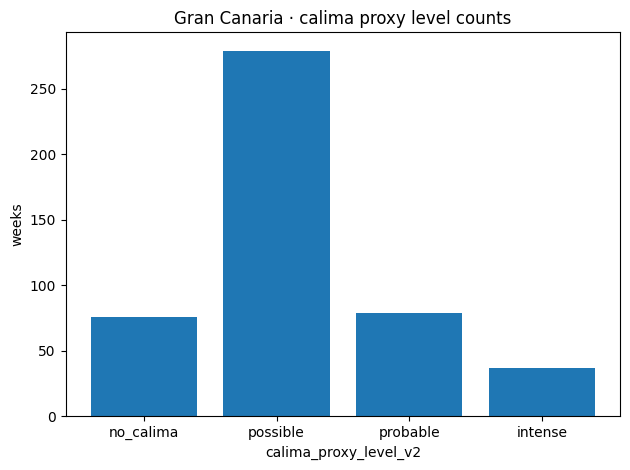

CAP yellow alignment with proxy (probable+intense among CAP yellow): 0.76


In [41]:
proxy_cols = ["calima_proxy_score_v2", "calima_proxy_level_v2"]
have_proxy = all(c in df.columns for c in proxy_cols)

if have_proxy:
    proxy_na = df[proxy_cols].isna().sum().rename("missing").to_frame()
    proxy_na["missing_pct"] = (proxy_na["missing"] / len(df)).round(4)
    display(proxy_na)
    save_table(proxy_na.reset_index().rename(columns={"index": "column"}), TAB_DIR, "calima_proxy_audit_missing_gcan.csv", index=False)

    proxy_counts = (
        df["calima_proxy_level_v2"]
        .value_counts(dropna=False)
        .rename_axis("calima_proxy_level_v2")
        .reset_index(name="weeks")
    )
    display(proxy_counts)
    save_table(proxy_counts, TAB_DIR, "calima_proxy_level_counts_gcan.csv", index=False)

    plot_counts = df["calima_proxy_level_v2"].dropna().value_counts()
    if not plot_counts.empty:
        desired_order = ["no_calima", "possible", "probable", "intense"]
        plot_counts = plot_counts.reindex([x for x in desired_order if x in plot_counts.index])

        plt.figure()
        plt.bar(plot_counts.index.astype(str), plot_counts.values)
        plt.title("Gran Canaria · calima proxy level counts")
        plt.xlabel("calima_proxy_level_v2")
        plt.ylabel("weeks")
        plt.tight_layout()
        autosave_fig(plt.gcf(), FIG_DIR, "gcan_eda01_calima_proxy_level_counts.png")
        plt.show()

    if {"cap_dust_yellow_plus_week", "calima_proxy_level_v2"}.issubset(df.columns):
        tmp = df.copy()
        tmp["proxy_ge_probable"] = tmp["calima_proxy_level_v2"].isin(["probable", "intense"])
        cap_yellow = tmp["cap_dust_yellow_plus_week"] == 1
        alignment = tmp.loc[cap_yellow, "proxy_ge_probable"].mean()
        print("CAP yellow alignment with proxy (probable+intense among CAP yellow):", round(float(alignment), 4))
else:
    print("No calima proxy level column found in this master.")


### 6.2 Calima levels and deaths
Compare weekly deaths across calima proxy levels (or DAI fallback if proxy columns are unavailable).


In [42]:
if "calima_proxy_level_v2" in df.columns:
    cal = df.groupby("calima_proxy_level_v2")["deaths_week"].agg(["count", "mean", "median"])
    level_order = ["no_calima", "possible", "probable", "intense"]
    cal = cal.reindex([x for x in level_order if x in cal.index])
    display(cal)
    save_table(cal.reset_index(), TAB_DIR, "calima_proxy_level_v2_deaths_gcan.csv", index=False)
else:
    print("No calima_proxy_level_v2. Using calima_dai_flag if available...")
    if "calima_dai_flag" in df.columns:
        cal = df.groupby("calima_dai_flag")["deaths_week"].agg(["count", "mean", "median"]).sort_index()
        display(cal)
        save_table(cal.reset_index(), TAB_DIR, "calima_dai_flag_deaths_gcan.csv", index=False)


,count,mean,median
calima_proxy_level_v2,,,
no_calima,76,138.026316,137.0
possible,279,130.788530,129.0
probable,79,133.949367,130.0
intense,37,154.000000,150.0


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gran_canaria\calima_proxy_level_v2_deaths_gcan.csv


## 7. Interaction: extreme heat × calima
A simple 2×2 cross-tab.


In [43]:
tmp = df.copy()

if "calima_proxy_level_v2" in tmp.columns:
    tmp["calima_intense"] = (tmp["calima_proxy_level_v2"] == "intense").astype(int)
else:
    tmp["calima_intense"] = 0

inter = tmp.groupby(["heat_p95", "calima_intense"])["deaths_week"].agg(["count", "mean", "median"])
display(inter)

save_table(inter.reset_index(), TAB_DIR, "interaction_heat_p95_x_calima_intense_gcan.csv", index=False)


count        mean  median
heat_p95 calima_intense                           
0        0                 411  132.389294   131.0
         1                  35  155.400000   150.0
1        0                  23  136.956522   136.0
         1                   2  129.500000   129.5

Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gran_canaria\interaction_heat_p95_x_calima_intense_gcan.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/gran_canaria/interaction_heat_p95_x_calima_intense_gcan.csv')

### Key numbers to report
- Δ deaths (heat p95 vs baseline): **+2.16**
- Δ deaths (calima intense vs baseline): **+23.00 deaths/week**
- Proxy coverage / missingness: **471/471 weeks covered, 0 missing (0.0%)**
- CAP yellow alignment with proxy: **76.0%**
- corr(deaths, tmax_c_mean): **-0.365**
- corr(deaths, Tmax anomaly): **0.082**

### Narrative summary

The Gran Canaria weekly audit shows a dataset with full proxy coverage and no missing calima proxy values across the study period. Core QA checks are acceptable for descriptive analysis, and the merged weekly structure supports comparison across mortality, temperature, and calima-related indicators.

The temperature signal follows the same broad pattern seen in Tenerife: raw `tmax_c_mean` is negatively correlated with deaths (`r = -0.365`), which is consistent with strong seasonal structure rather than a protective effect of heat. Once seasonality is partially reduced through Tmax anomaly, the association becomes weakly positive (`r = 0.082`), suggesting that short-term temperature departures may contain a small signal that is obscured in raw seasonal comparisons.

Using a simple weekly threshold definition, heat p95 weeks show only a modest increase in mean deaths relative to baseline (`+2.16` deaths/week). By contrast, intense calima weeks show a much larger difference (`+23.00` deaths/week), making calima intensity the more prominent descriptive signal in this audit. CAP yellow weeks also show reasonably strong agreement with the proxy (`76.0%` alignment), which supports the usefulness of the derived weekly calima classification as an operational indicator.

Overall, the Gran Canaria EDA suggests that intense calima is more clearly associated with elevated weekly mortality than extreme heat alone under this specification. However, when de-seasonalising by week-of-year, the continuous calima score shows near-zero correlation with mortality anomalies, suggesting that the strong ‘intense vs baseline’ contrast is largely driven by shared seasonality rather than within-season variation. Heat may still matter, but its isolated weekly signal appears weaker and more sensitive to definition and seasonal confounding. These results remain descriptive and should not be interpreted causally, but they provide a coherent basis for cross-island comparison and for later lagged or seasonally adjusted modelling.